In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("student_multiple_features.csv")

In [3]:
df

,Student,StudyHours,Attendance,PreviousMarks,FinalMarks
0,Aarav,2,70,38.0,42
1,Sita,3,75,45.0,50
2,Ram,4,80,52.0,58
3,Anisha,5,85,60.0,68
4,Rohan,6,90,68.0,78
5,Priya,7,92,75.0,85
6,Kiran,8,95,82.0,92
7,Nabin,4,78,55.0,60
8,Suman,5,82,63.0,70
9,Alisha,6,88,70.0,79


In [4]:
df.head()

,Student,StudyHours,Attendance,PreviousMarks,FinalMarks
0,Aarav,2,70,38.0,42
1,Sita,3,75,45.0,50
2,Ram,4,80,52.0,58
3,Anisha,5,85,60.0,68
4,Rohan,6,90,68.0,78


In [5]:
X =df[["StudyHours"]]
y = df["FinalMarks"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
X_train

,StudyHours
8,5
5,7
11,8
3,5
18,8
16,4
13,9
2,4
9,6
19,5


In [8]:
X_test

,StudyHours
0,2
17,7
15,6
1,3


In [9]:
model = LogisticRegression()

In [10]:
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [11]:
predict = model.predict(X_test)

In [12]:
print(predict)

[52 92 79 52]


In [13]:
comparision = pd.DataFrame({
    "Actual": y_test,
    "predicted": predict
})

In [14]:
comparision

,Actual,predicted
0,42,52
17,89,92
15,81,79
1,50,52


In [15]:
accuracy =  accuracy_score(y_test, predict)

In [16]:
print(accuracy)

0.0


In [17]:
print(accuracy * 100, "%")

0.0 %


In [18]:
new_student = pd.DataFrame({
    "StudyHours": [5.5]
})
new_prediction = model.predict(new_student)

In [19]:
new_prediction

array([70])

In [21]:
probability =  model.predict_proba(new_student)
probability

array([[0.03870703, 0.06712134, 0.06712134, 0.06712134, 0.0836902 ,
        0.0836902 , 0.0836902 , 0.0836902 , 0.08140356, 0.08140356,
        0.06423335, 0.06423335, 0.03925173, 0.0392517 , 0.03925136,
        0.01613955]])

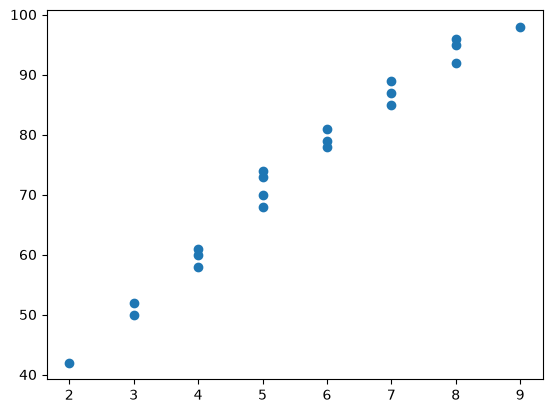

In [27]:
plt.scatter(df["StudyHours"], df["FinalMarks"])
